In [1]:
!pip install opencv-python

In [3]:
import os
import time
import copy
import glob
import cv2 # 앞에서 설치한 OpenCV 라이브러리
import shutil

import torch
import torchvision #컴퓨터 비전(computer vision) 용도의 패키지
import torchvision.transforms as transforms #데이터 전처리를 위해 사용되는 패키지
import torchvision.models as models #다양한 파이토치 네트워크를 사용할 수 있도록 도와주는 패키지
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [5]:
# 이미지 데이터에 대한 전처리 방법 정의
data_path='/Users/bluecloud/Documents/대학/유런/data/catanddog/train'
transform=transforms.Compose([
    transforms.Resize([256, 256]),
    transforms.RandomResizedCrop(224) ,
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()    
])
train_dataset=torchvision.datasets.ImageFolder(data_path,transform=transform)
train_loader=torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8,
    shuffle=True
)
print(len(train_dataset))

385


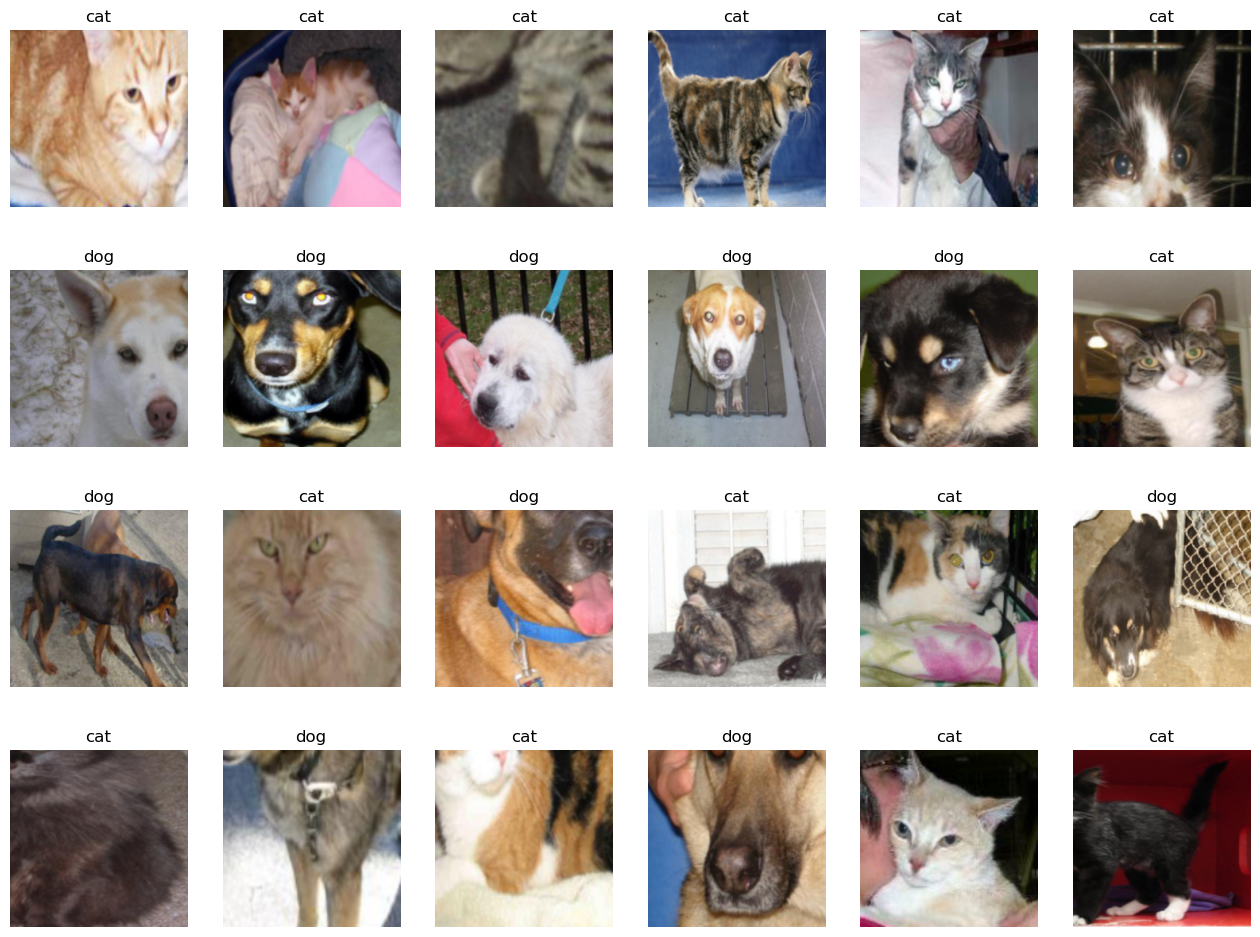

In [7]:
#학습에 사용될 24개의 이미지 출력
import numpy as np
samples, labels = next(iter(train_loader))
classes = {0:'cat', 1:'dog'} # 개와 고양이에 대한 클래스로 구성
fig = plt.figure(figsize=(16,24))
for i in range(24): #24 개의 이미지 데이터 출력
    a = fig.add_subplot(4,6,i+1)
    a.set_title(classes[labels[i].item()]) # 레이블 정보 ( 클래스 ) 를 함께 출력
    a.axis('off')
    a.imshow(np.transpose(samples[i].numpy(), (1,2,0))) 
plt. subplots_adjust(bottom=0.2, top=0.6, hspace=0)

In [9]:
print(samples.shape)

torch.Size([32, 3, 224, 224])


In [9]:
#사전훈련된 ResNet18모델 내려받기
resnet18=models.resnet18(pretrained=True)

/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
#합성곱층을 고정하여 훈련하지 않도록 고정
def set_parameter_requires_grad(model, feature_extracting=True):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False 
set_parameter_requires_grad(resnet18)

In [13]:
#ResNet18에 완전 연결층을 추가하고 모델의 파라미터 값 확인하기
resnet18.fc=nn.Linear(512,2) # 클래스가 2개

for name,param in resnet18.named_parameters():
    if param.requires_grad:
        print(name,param.data)
    

fc.weight tensor([[-0.0194, -0.0419, -0.0168,  ..., -0.0386,  0.0353, -0.0387],
        [-0.0130, -0.0061,  0.0182,  ...,  0.0413,  0.0375,  0.0364]])
fc.bias tensor([-0.0342, -0.0142])


In [15]:
#모델 객체 생성 및 손실 함수 정의
model = models.resnet18(pretrained=True) #모델의 객체 생성

for param in model.parameters(): # 모델의 합성곱충 가중치 고정
    param.requires_grad = False
    
model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters(): # 완전연결층은 학습
    param. requires_grad = True
    
optimizer = torch.optim.Adam(model. fc.parameters())
cost = torch.nn.CrossEntropyLoss() #손실 함수 정의
print (model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [17]:
#모델 학습을 위한 함수 생성
def train_model(model,dataloaders,criterion, optimizer,device, num_epochs=13,is_train=True):
    since=time.time() #컴퓨터의 현재 시각을 구하는 함수
    acc_history = []
    loss_history = []
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch,num_epochs-1))
        print('-'*10)
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders: #데이터로더에 전달된 데이터만큼 반복
            inputs = inputs.to(device)
            labels = labels.to(device)
            model.to(device)
            optimizer.zero_grad() #기울기를 0으로 설정
            outputs=model(inputs) #순전파
            loss=criterion(outputs,labels)
            _, preds = torch.max(outputs, 1)
            loss.backward() #역전파 학습
            optimizer.step()

            running_loss+=loss.item()*inputs.size(0) #출력 결과와 레이블의 오차를 계산한 결과를 누적하여 저장
            running_corrects+=torch.sum(preds == labels.data) #출력 결과와 레이블이 동일한지 확인한 결과를 누적하여 저장
            
        epoch_loss=running_loss/len(dataloaders.dataset) #평균 오차 계산
        epoch_acc=running_corrects.double()/len(dataloaders.dataset) #평균 정확도 
        print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))
        if epoch_acc > best_acc:
            best_acc = epoch_acc
        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)
        #모델 재사용을 위한 저장
        torch.save(model.state_dict(),os.path.join('/Users/bluecloud/Documents/대학/유런/data/catanddog/','{0:0=2d}.pth'.format(epoch)))
        print()
    time_elapsed= time.time()-since # 실행 시간 ( 학습 시간 ) 을 계산
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60,time_elapsed%60))
    print('Best Acc: {:4f}'. format(best_acc))
    return acc_history, loss_history #모델의 정확도와 오차를 반환


In [19]:
#추가된 완전연결층을 학습하고 얻어지는 파라미터를 옵티마이저에 전달해서 전달
params_to_update = []
for name, param in resnet18.named_parameters():
    if param.requires_grad == True:
        params_to_update. append (param)#파라미터 학습 결과를 저장
        print("\t", name)
optimizer = optim.Adam(params_to_update) #학습 결과를 옵티마이저에 전달

	 fc.weight
	 fc.bias


In [21]:
#모델 학습
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion=nn.CrossEntropyLoss() #손실함수 지정
#모델의 정확도와 오차를 반환
train_acc_hist,train_loss_hist=train_model(resnet18,train_loader,criterion,optimizer,device)

Epoch 0/12
----------
Loss: 0.6319 Acc: 0.6312

Epoch 1/12
----------
Loss: 0.3907 Acc: 0.8675

Epoch 2/12
----------
Loss: 0.3134 Acc: 0.9143

Epoch 3/12
----------
Loss: 0.2958 Acc: 0.8753

Epoch 4/12
----------
Loss: 0.2530 Acc: 0.9091

Epoch 5/12
----------
Loss: 0.1970 Acc: 0.9377

Epoch 6/12
----------
Loss: 0.2355 Acc: 0.9013

Epoch 7/12
----------
Loss: 0.2031 Acc: 0.9299

Epoch 8/12
----------
Loss: 0.2167 Acc: 0.9325

Epoch 9/12
----------
Loss: 0.2074 Acc: 0.9221

Epoch 10/12
----------
Loss: 0.2433 Acc: 0.8961

Epoch 11/12
----------
Loss: 0.2212 Acc: 0.9039

Epoch 12/12
----------
Loss: 0.1991 Acc: 0.9247

Training complete in 13m 48s
Best Acc: 0.937662


[테스트 데이터로 모델 정확도 측정하기]

In [23]:
# 테스트 데이터 호출 및 전처리
test_path='/Users/bluecloud/Documents/대학/유런/data/catanddog/test'
transform=transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224) ,
    transforms.ToTensor()    
])
test_dataset=torchvision.datasets.ImageFolder(root=test_path,transform=transform)
test_loader=torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)
print(len(test_dataset))

98


In [25]:
# 테스트 데이터 평가를 위한 함수를 생성
def eval_model(model,dataloaders,device) :
    since = time.time()
    acc_history = []
    best_acc = 0.0
    
    saved_models = glob.glob('/Users/bluecloud/Documents/대학/유런/data/catanddog/'+'*.pth') 
    saved_models.sort() #불러온 .pth 파일들을 정렬
    print( 'saved_model' , saved_models)
    
    for model_path in saved_models:
        print('Loading model', model_path)
        model.load_state_dict(torch.load(model_path))
        model.eval()
        model.to(device)
        running_corrects = 0
        
        for inputs, labels in dataloaders: # 테스트 반복
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            with torch.no_grad(): #autograd를 사용하지 않겠다는 의미
                outputs = model(inputs) #데이터를 모델에 적용한 결과를 outputs에 저장
            _,preds = torch.max(outputs.data, 1) 
            preds[preds>= 0.5] = 1 # torch.max로 출력된 값이 0.5 보다 크면 올바르게 예측
            preds[preds<0.5] = 0 #torch.max 로 출력된 값이 0.5 보다 작으면 틀리게 예측
            running_corrects += preds.eq(labels.cpu()).int().sum()
            
        epoch_acc = running_corrects.double() / len(dataloaders.dataset) #테스트 데이터의 정확도 계산
        print('Acc: {:.4f}'.format(epoch_acc)) 
        
        if epoch_acc > best_acc:
            best_acc = epoch_acc
        acc_history.append(epoch_acc.item())
        print()
        
    time_elapsed = time.time()-since
    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed//60,time_elapsed%60))
    print('Best Acc: {:4f}'.format(best_acc))
    return acc_history #계산된 정확도 반환

In [27]:
#추가된 완전연결층을 학습하고 얻어지는 파라미터를 옵티마이저에 전달해서 전달
params_to_update = []
for name, param in resnet18.named_parameters():
    if param.requires_grad == True:
        params_to_update. append (param)#파라미터 학습 결과를 저장
        print("\t", name)
optimizer = optim.Adam(params_to_update) #학습 결과를 옵티마이저에 전달

	 fc.weight
	 fc.bias


In [29]:
# 적용
val_acc_hist = eval_model(resnet18,test_loader,device)

saved_model ['/Users/bluecloud/Documents/대학/유런/data/catanddog/00.pth', '/Users/bluecloud/Documents/대학/유런/data/catanddog/01.pth', '/Users/bluecloud/Documents/대학/유런/data/catanddog/02.pth', '/Users/bluecloud/Documents/대학/유런/data/catanddog/03.pth', '/Users/bluecloud/Documents/대학/유런/data/catanddog/04.pth', '/Users/bluecloud/Documents/대학/유런/data/catanddog/05.pth', '/Users/bluecloud/Documents/대학/유런/data/catanddog/06.pth', '/Users/bluecloud/Documents/대학/유런/data/catanddog/07.pth', '/Users/bluecloud/Documents/대학/유런/data/catanddog/08.pth', '/Users/bluecloud/Documents/대학/유런/data/catanddog/09.pth', '/Users/bluecloud/Documents/대학/유런/data/catanddog/10.pth', '/Users/bluecloud/Documents/대학/유런/data/catanddog/11.pth', '/Users/bluecloud/Documents/대학/유런/data/catanddog/12.pth']
Loading model /Users/bluecloud/Documents/대학/유런/data/catanddog/00.pth
Acc: 0.9082

Loading model /Users/bluecloud/Documents/대학/유런/data/catanddog

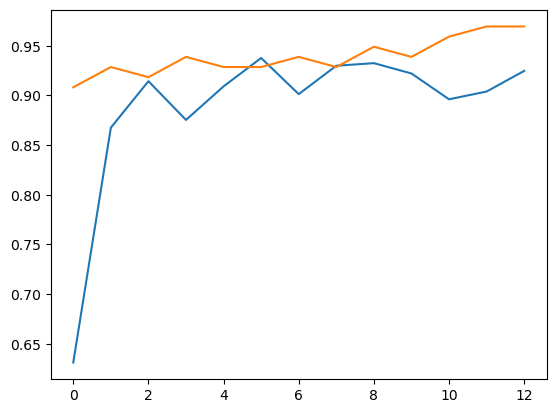

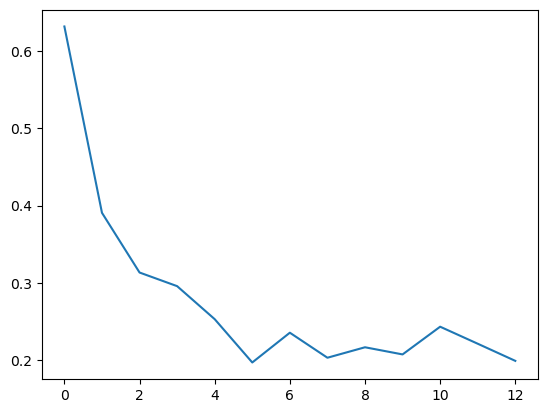

In [31]:
# 훈련과 테스트 데이터 정확도 및 오차 정보 그래프 그리기
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

plt. plot(train_loss_hist)
plt. show()


In [33]:
def im_convert(tensor) :
    image = tensor.clone().detach().numpy() 
    image = image.transpose(1, 2, 0)
    image = image *(np.array((0.5,0.5,0.5))+np.array((0.5,0.5,0.5)))
    image = image.clip(0, 1)
    return image

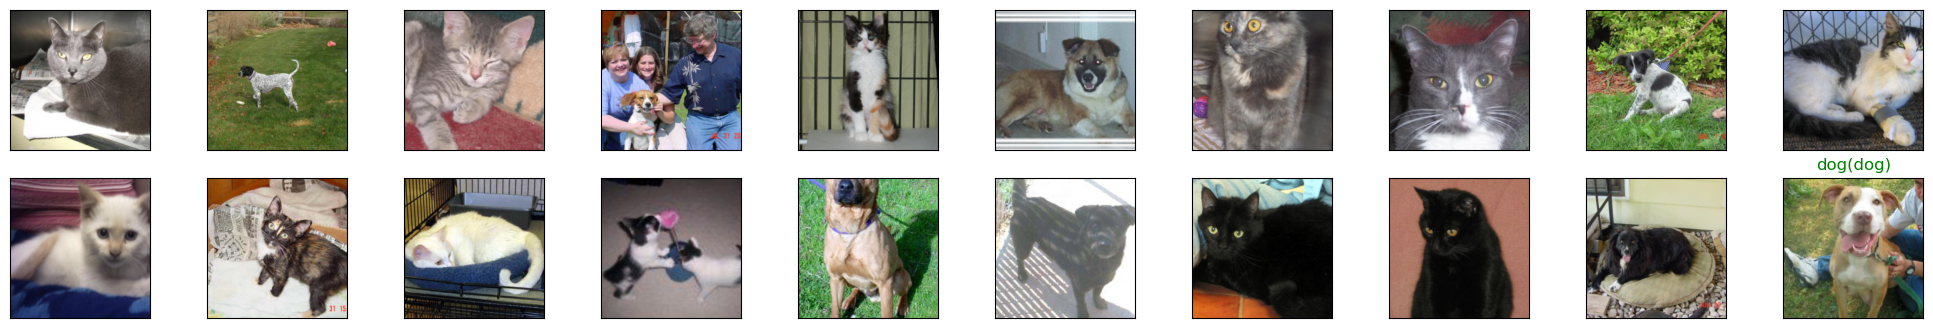

<Figure size 640x480 with 0 Axes>

In [39]:
classes = {0:'cat', 1:'dog'} #개와 고양이 두 개에 대한 레이블

dataiter = iter(test_loader) #테스트 데이터셋을 가져옵니다.
images, labels = next(dataiter) #테스트 데이터셋에서 이미지와 레이블을 분리하여 가져옵니다.
output = model(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25,4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
    plt.imshow(im_convert(images[idx])) #이미지 출력을 위해 코드 5-28 에서 정의한 im_convert 함수를 적용
    a.set_title(classes[labels[i].item()])
ax.set_title("{}({})".format(str(classes[preds[idx].item()]), str(classes[labels[idx].item()])), color=("green" if preds[idx]==labels[idx] else "red"))

plt. show( )
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

# 4. 설명 가능한 CNN

In [41]:
!pip install pillow

In [43]:
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn. functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
import torchvision

import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [45]:
class XAI(torch.nn.Module):
    def __init__(self, num_classes=2):
        super(XAI, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Conv2d(64, 64, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(128, 128, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(256, 256, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(256, 256, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(512, 512, bias=False),
            nn.Dropout(0.5),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(-1, 512)
        x = self.classifier(x)
        return F.log_softmax(x)

In [47]:
model=XAI()
model.to(device)
model.eval()

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

In [49]:
class LayerActivations:
    features=[]
    def __init__(self, model, layer_num):
        self.hook = model[layer_num].register_forward_hook(self.hook_fn)
    def hook_fn(self, module, input, output):
        output = output
        self.features = output.to(device).detach().numpy()
    def remove(self): 
        self.hook.remove()

torch.Size([1, 3, 100, 100])


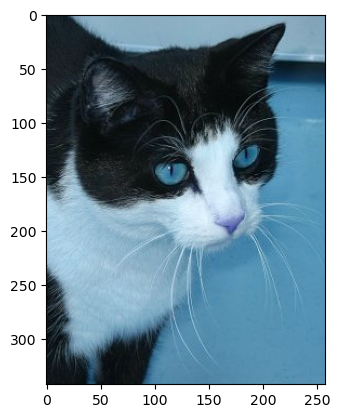

In [57]:
img=cv2.imread("/Users/bluecloud/Documents/대학/유런/data/catanddog/test/Cat/8113.jpg")   
plt.imshow(img)
img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR)
img = ToTensor()(img).unsqueeze(0)
print(img.shape)


In [59]:
result = LayerActivations(model.features, 0)
model(img)
activations = result.features

/var/folders/2c/j3wmswps2r5gclvj1skrczqh0000gn/T/ipykernel_57463/1460188688.py:75: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


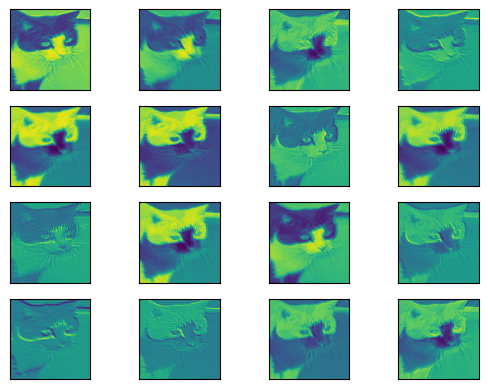

<Figure size 1200x800 with 0 Axes>

In [61]:
fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
plt.show()

/var/folders/2c/j3wmswps2r5gclvj1skrczqh0000gn/T/ipykernel_57463/1460188688.py:75: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


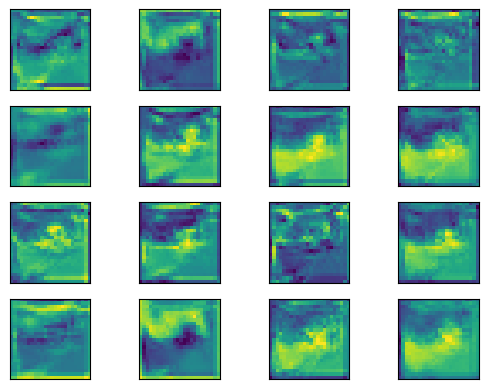

<Figure size 1200x800 with 0 Axes>

In [63]:
result = LayerActivations(model.features, 20)

model(img)
activations = result.features

fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
plt.show()

/var/folders/2c/j3wmswps2r5gclvj1skrczqh0000gn/T/ipykernel_57463/1460188688.py:75: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


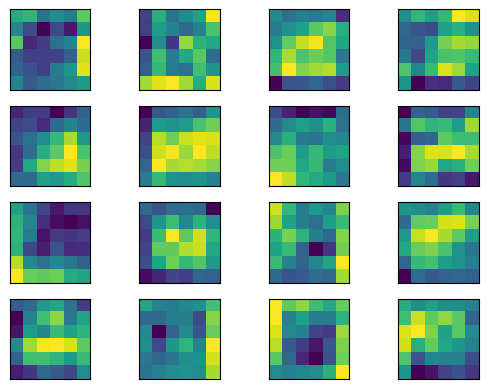

<Figure size 1200x800 with 0 Axes>

In [65]:
result = LayerActivations(model.features, 40)

model(img)
activations = result.features

fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
plt.show()